# ERCOT Heat Rates and Spark Spreads Analysis

## Dataset Selection

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Step 1: Load ERCOT DAM Electricity Prices

In [5]:
gas_df = pd.read_csv('data/Henry_Hub_Natural_Gas_Spot_Price.csv', skiprows=4)
gas_df.columns = ['Date', 'Gas_Price']

gas_df['Date'] = pd.to_datetime(gas_df['Date'])
gas_df = gas_df.sort_values('Date').reset_index(drop=True)
gas_df.set_index('Date', inplace=True)

gas_df.tail(10)

,Gas_Price
Date,
2025-12-04,4.89
2025-12-05,5.19
2025-12-08,5.19
2025-12-09,4.76
2025-12-10,4.62
2025-12-11,4.35
2025-12-12,4.07
2025-12-15,3.90
2025-12-16,3.58


In [6]:
# Load ERCOT DAM Load Zone and Hub Prices
ercot_file = 'data/rpt.00013060.0000000000000000.DAMLZHBSPP_2025.xlsx'

# Read ALL sheets from the Excel file
all_sheets = pd.read_excel(ercot_file, sheet_name=None)
ercot_df = pd.concat(all_sheets.values(), ignore_index=True)

ercot_df.head(10)

,Delivery Date,Hour Ending,Repeated Hour Flag,Settlement Point,Settlement Point Price
0,01/01/2025,01:00,N,HB_BUSAVG,23.00
1,01/01/2025,01:00,N,HB_HOUSTON,22.87
2,01/01/2025,01:00,N,HB_HUBAVG,23.07
3,01/01/2025,01:00,N,HB_NORTH,22.96
4,01/01/2025,01:00,N,HB_PAN,23.15
5,01/01/2025,01:00,N,HB_SOUTH,22.79
6,01/01/2025,01:00,N,HB_WEST,23.67
7,01/01/2025,01:00,N,LZ_AEN,22.80
8,01/01/2025,01:00,N,LZ_CPS,22.77
9,01/01/2025,01:00,N,LZ_HOUSTON,22.87


In [7]:
date_col = 'Delivery Date'
price_col = 'Settlement Point Price'
point_col = 'Settlement Point'

print(f"  Settlement Point column: {point_col}")

# Show unique settlement points
print(f"\nAll available Settlement Points:")
print(ercot_df[point_col].unique())

  Settlement Point column: Settlement Point

All available Settlement Points:
['HB_BUSAVG' 'HB_HOUSTON' 'HB_HUBAVG' 'HB_NORTH' 'HB_PAN' 'HB_SOUTH'
 'HB_WEST' 'LZ_AEN' 'LZ_CPS' 'LZ_HOUSTON' 'LZ_LCRA' 'LZ_NORTH' 'LZ_RAYBN'
 'LZ_SOUTH' 'LZ_WEST']


In [8]:
# Narrowing to target hubs
target_hubs = ['HB_HOUSTON', 'HB_NORTH', 'HB_SOUTH', 'HB_WEST']

ercot_df[date_col] = pd.to_datetime(ercot_df[date_col])
hub_df = ercot_df[ercot_df[point_col].isin(target_hubs)].copy()

print(f"Filtered for target hubs: {target_hubs}")
print(f"\nRecords per hub:")
print(hub_df[point_col].value_counts())

Filtered for target hubs: ['HB_HOUSTON', 'HB_NORTH', 'HB_SOUTH', 'HB_WEST']

Records per hub:
Settlement Point
HB_HOUSTON    8328
HB_NORTH      8328
HB_SOUTH      8328
HB_WEST       8328
Name: count, dtype: int64


In [9]:
# Aggregate hourly data to daily statistics for each hub
daily_elec = hub_df.groupby([point_col, pd.Grouper(key=date_col, freq='D')]).agg(
    Price_Mean=(price_col, 'mean'),
    Price_Min=(price_col, 'min'),
    Price_Max=(price_col, 'max'),
    Price_Std=(price_col, 'std'),
    Hour_Count=(price_col, 'count')
).reset_index()

daily_elec.columns = ['Hub', 'Date', 'Elec_Price_Mean', 'Elec_Price_Min', 'Elec_Price_Max', 'Elec_Price_Std', 'Hours']

print(f"Daily Electricity Prices by Hub")
print(f"="*50)
print(f"Date Range: {daily_elec['Date'].min().date()} to {daily_elec['Date'].max().date()}")
print(f"\nRecords per Hub:")
print(daily_elec.groupby('Hub').size())

daily_elec.head(3)

Daily Electricity Prices by Hub
Date Range: 2025-01-01 to 2025-12-13

Records per Hub:
Hub
HB_HOUSTON    347
HB_NORTH      347
HB_SOUTH      347
HB_WEST       347
dtype: int64


,Hub,Date,Elec_Price_Mean,Elec_Price_Min,Elec_Price_Max,Elec_Price_Std,Hours
0,HB_HOUSTON,2025-01-01,21.907917,14.34,36.75,5.765422,24
1,HB_HOUSTON,2025-01-02,22.997500,16.68,38.72,5.351980,24
2,HB_HOUSTON,2025-01-03,22.896250,9.52,40.38,7.191178,24


In [10]:
# Display price statistics by hub
if 'daily_elec' in dir():
    print("Electricity Price Statistics by Hub ($/MWh)")
    print("="*60)
    
    for hub in daily_elec['Hub'].unique():
        hub_data = daily_elec[daily_elec['Hub'] == hub]
        print(f"\n{hub}:")
        print(f"  Mean Price:  ${hub_data['Elec_Price_Mean'].mean():.2f}/MWh")
        print(f"  Min Price:   ${hub_data['Elec_Price_Min'].min()}/MWh")
        print(f"  Max Price:   ${hub_data['Elec_Price_Max'].max()}/MWh")
        print(f"  Avg Daily Range: ${(hub_data['Elec_Price_Max'] - hub_data['Elec_Price_Min']).mean():.2f}/MWh")

Electricity Price Statistics by Hub ($/MWh)

HB_HOUSTON:
  Mean Price:  $34.97/MWh
  Min Price:   $-0.1/MWh
  Max Price:   $772.08/MWh
  Avg Daily Range: $62.19/MWh

HB_NORTH:
  Mean Price:  $33.24/MWh
  Min Price:   $0.0/MWh
  Max Price:   $913.72/MWh
  Avg Daily Range: $66.42/MWh

HB_SOUTH:
  Mean Price:  $33.18/MWh
  Min Price:   $-1.81/MWh
  Max Price:   $658.8/MWh
  Avg Daily Range: $61.29/MWh

HB_WEST:
  Mean Price:  $34.12/MWh
  Min Price:   $-13.21/MWh
  Max Price:   $911.12/MWh
  Avg Daily Range: $73.36/MWh


In [11]:
print("\n NATURAL GAS (Henry Hub)")
print(f"   Date Range: {gas_df.index.min().date()} to {gas_df.index.max().date()}")
print(f"   Trading Days: {len(gas_df):,}")

if 'daily_elec' in dir():
    print("\n ELECTRICITY (ERCOT DAM)")
    print(f"   Date Range: {daily_elec['Date'].min().date()} to {daily_elec['Date'].max().date()}")
    print(f"   Daily Records: {len(daily_elec):,}")
    
    # Find overlapping dates
    elec_dates = set(daily_elec['Date'].dt.date)
    gas_dates = set(gas_df.index.date)
    overlap_dates = elec_dates.intersection(gas_dates)
    
    print(f"\n OVERLAPPING DATES: {len(overlap_dates)} days")
    if overlap_dates:
        print(f"   From: {min(overlap_dates)} to {max(overlap_dates)}")
    


 NATURAL GAS (Henry Hub)
   Date Range: 1997-01-07 to 2025-12-17
   Trading Days: 7,273

 ELECTRICITY (ERCOT DAM)
   Date Range: 2025-01-01 to 2025-12-13
   Daily Records: 1,388

 OVERLAPPING DATES: 237 days
   From: 2025-01-02 to 2025-12-12


## Next Steps: Heat Rate & Spark Spread Calculations

### Definitions:

**Implied Heat Rate** = Electricity Price ($/MWh) ÷ Gas Price ($/MMBtu)
- Units: MMBtu/MWh (or Btu/kWh × 1000)
- Interpretation: How efficiently the market is valuing gas-to-power conversion
- Typical range: 7-15 MMBtu/MWh for efficient gas plants

**Spark Spread** = Electricity Price ($/MWh) - (Gas Price ($/MMBtu) × Heat Rate)
- Units: $/MWh
- Interpretation: Gross margin for a gas-fired power plant
- Positive = profitable generation, Negative = unprofitable

In [ ]:
print("Most Recent Henry Hub Natural Gas Prices ($/MMBtu)")
print("="*50)
gas_df.tail(2)

Most Recent Henry Hub Natural Gas Prices ($/MMBtu)


,Gas_Price
Date,
2025-12-16,3.58
2025-12-17,3.66


In [19]:
print("Most Recent ERCOT DAM Hub Prices ($/MWh)")
print("="*50)
daily_elec.tail(5)

Most Recent ERCOT DAM Hub Prices ($/MWh)


,Hub,Date,Elec_Price_Mean,Elec_Price_Min,Elec_Price_Max,Elec_Price_Std,Hours
1383,HB_WEST,2025-12-09,26.900417,0.66,59.92,16.516210,24
1384,HB_WEST,2025-12-10,33.514583,-4.67,81.86,28.931990,24
1385,HB_WEST,2025-12-11,24.069167,2.48,53.57,17.075413,24
1386,HB_WEST,2025-12-12,36.444167,11.22,63.98,16.826927,24
1387,HB_WEST,2025-12-13,51.069167,21.79,76.63,17.776418,24


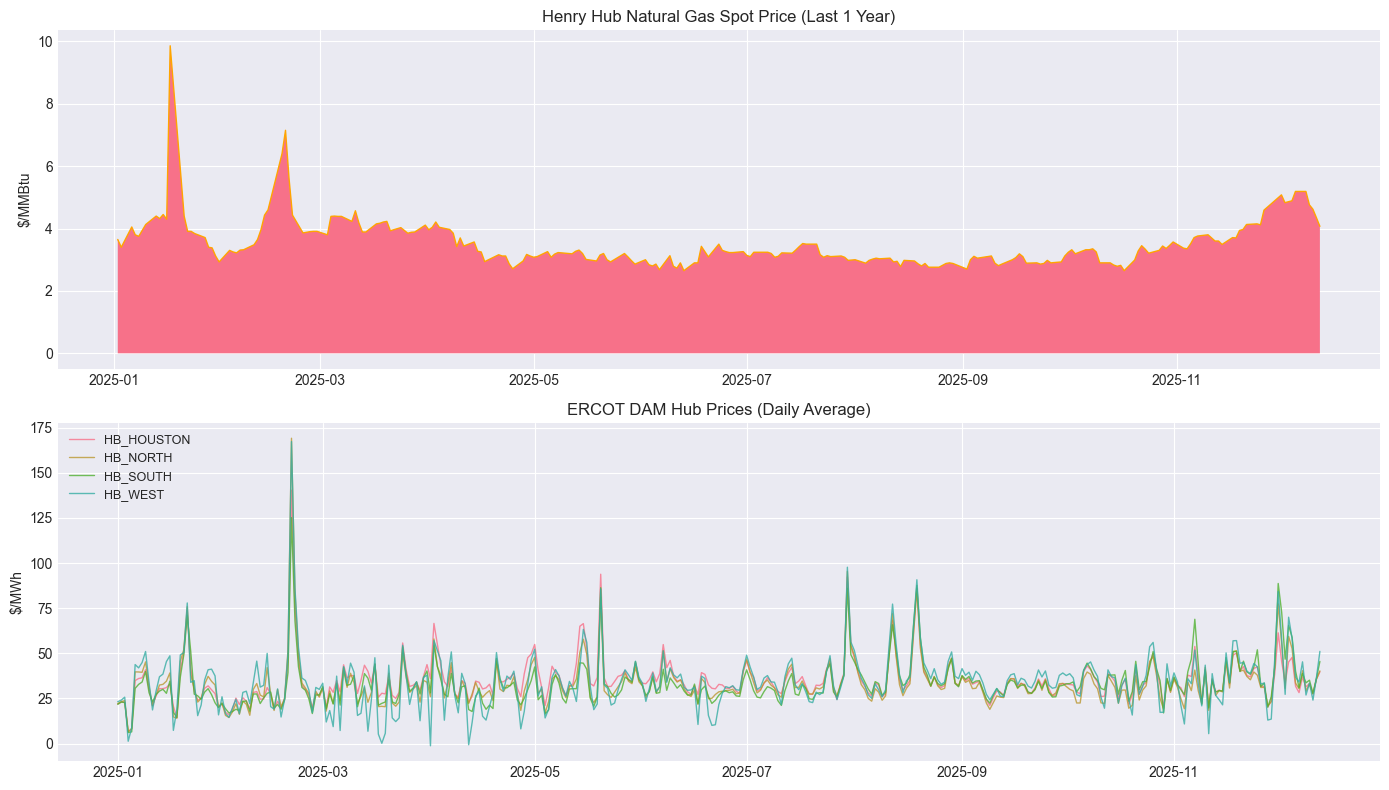

In [14]:
# Quick visualization 
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

gas_recent = gas_df.loc[(gas_df.index >= pd.to_datetime("2025-01-01")) & (gas_df.index <= pd.to_datetime("2025-12-13"))]
axes[0].plot(gas_recent.index, gas_recent['Gas_Price'], color='orange', linewidth=1)
axes[0].set_title('Henry Hub Natural Gas Spot Price (Last 1 Year)')
axes[0].set_ylabel('$/MMBtu')
axes[0].fill_between(gas_recent.index, gas_recent['Gas_Price'])

if 'daily_elec' in dir():
    for hub in daily_elec['Hub'].unique():
        hub_data = daily_elec[daily_elec['Hub'] == hub].set_index('Date')
        axes[1].plot(hub_data.index, hub_data['Elec_Price_Mean'], label=hub, linewidth=1, alpha=0.8)
    
    axes[1].set_title('ERCOT DAM Hub Prices (Daily Average)')
    axes[1].set_ylabel('$/MWh')
    axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# Merged dataset for 2025
gas_merge = gas_df.reset_index()[['Date', 'Gas_Price']]
analysis_df = daily_elec.merge(gas_merge, on='Date', how='inner')

analysis_df.head(2)

,Hub,Date,Elec_Price_Mean,Elec_Price_Min,Elec_Price_Max,Elec_Price_Std,Hours,Gas_Price
0,HB_HOUSTON,2025-01-02,22.99750,16.68,38.72,5.351980,24,3.65
1,HB_HOUSTON,2025-01-03,22.89625,9.52,40.38,7.191178,24,3.40


In [16]:
# Calculate Implied Heat Rate = Electricity Price / Gas Price
# Units: MMBtu/MWh (how many MMBtu of gas equivalent per MWh of electricity)

analysis_df['Implied_Heat_Rate'] = analysis_df['Elec_Price_Mean'] / analysis_df['Gas_Price']

print("IMPLIED HEAT RATE")
print("="*60)
print("Implied Heat Rate = Electricity Price ($/MWh) ÷ Gas Price ($/MMBtu)")
print("Typical efficient CCGT plant: 7-8 MMBtu/MWh")
print("Typical peaker plant: 9-12 MMBtu/MWh")
print("Source: https://www.eia.gov/todayinenergy/detail.php?id=52158")

for hub in analysis_df['Hub'].unique():
    hub_data = analysis_df[analysis_df['Hub'] == hub]
    print(f"\n{hub}:")
    print(f"  Mean Heat Rate:   {hub_data['Implied_Heat_Rate'].mean():.2f} MMBtu/MWh")
    print(f"  Median Heat Rate: {hub_data['Implied_Heat_Rate'].median():.2f} MMBtu/MWh")
    print(f"  Std Dev:          {hub_data['Implied_Heat_Rate'].std():.2f} MMBtu/MWh")
    print(f"  Min : Max:        {hub_data['Implied_Heat_Rate'].min():.2f} : {hub_data['Implied_Heat_Rate'].max():.2f}")

IMPLIED HEAT RATE
Implied Heat Rate = Electricity Price ($/MWh) ÷ Gas Price ($/MMBtu)
Typical efficient CCGT plant: 7-8 MMBtu/MWh
Typical peaker plant: 9-12 MMBtu/MWh
Source: https://www.eia.gov/todayinenergy/detail.php?id=52158

HB_HOUSTON:
  Mean Heat Rate:   10.87 MMBtu/MWh
  Median Heat Rate: 10.38 MMBtu/MWh
  Std Dev:          3.91 MMBtu/MWh
  Min : Max:        2.10 : 30.96

HB_NORTH:
  Mean Heat Rate:   10.24 MMBtu/MWh
  Median Heat Rate: 9.69 MMBtu/MWh
  Std Dev:          3.98 MMBtu/MWh
  Min : Max:        1.50 : 32.00

HB_SOUTH:
  Mean Heat Rate:   10.26 MMBtu/MWh
  Median Heat Rate: 9.79 MMBtu/MWh
  Std Dev:          3.83 MMBtu/MWh
  Min : Max:        1.76 : 30.52

HB_WEST:
  Mean Heat Rate:   10.64 MMBtu/MWh
  Median Heat Rate: 10.67 MMBtu/MWh
  Std Dev:          4.73 MMBtu/MWh
  Min : Max:        -0.31 : 32.78


In [17]:
# Spark Spread = Electricity Price - (Gas Price × Heat Rate)
# This represents the gross margin for a gas-fired power plant

# Define heat rates for different plant types
CCGT_HEAT_RATE = 7.0    # Efficient combined-cycle gas turbine
PEAKER_HEAT_RATE = 10.0  # Less efficient peaking plant

analysis_df['Spark_Spread_CCGT'] = analysis_df['Elec_Price_Mean'] - (analysis_df['Gas_Price'] * CCGT_HEAT_RATE)
analysis_df['Spark_Spread_Peaker'] = analysis_df['Elec_Price_Mean'] - (analysis_df['Gas_Price'] * PEAKER_HEAT_RATE)

print("SPARK SPREAD ANALYSIS")
print("="*60)
print(f"CCGT Heat Rate: {CCGT_HEAT_RATE} MMBtu/MWh (efficient baseload plant)")
print(f"Peaker Heat Rate: {PEAKER_HEAT_RATE} MMBtu/MWh (less efficient peaking plant)")
print("\nSpark Spread = Elec Price - (Gas Price × Heat Rate)")
print("Positive = profitable to generate | Negative = uneconomic")
print("Source: https://www.eia.gov/todayinenergy/detail.php?id=52158")

for hub in analysis_df['Hub'].unique():
    hub_data = analysis_df[analysis_df['Hub'] == hub]
    ccgt_profitable = (hub_data['Spark_Spread_CCGT'] > 0).sum()
    peaker_profitable = (hub_data['Spark_Spread_Peaker'] > 0).sum()
    total_days = len(hub_data)
    
    print(f"\n{hub}:")
    print(f"  CCGT Spark Spread:")
    print(f"    Mean: ${hub_data['Spark_Spread_CCGT'].mean():.2f}/MWh")
    print(f"    Profitable Days: {ccgt_profitable}/{total_days} ({100*ccgt_profitable/total_days:.1f}%)")
    print(f"  Peaker Spark Spread:")
    print(f"    Mean: ${hub_data['Spark_Spread_Peaker'].mean():.2f}/MWh")
    print(f"    Profitable Days: {peaker_profitable}/{total_days} ({100*peaker_profitable/total_days:.1f}%)")

SPARK SPREAD ANALYSIS
CCGT Heat Rate: 7.0 MMBtu/MWh (efficient baseload plant)
Peaker Heat Rate: 10.0 MMBtu/MWh (less efficient peaking plant)

Spark Spread = Elec Price - (Gas Price × Heat Rate)
Positive = profitable to generate | Negative = uneconomic
Source: https://www.eia.gov/todayinenergy/detail.php?id=52158

HB_HOUSTON:
  CCGT Spark Spread:
    Mean: $12.42/MWh
    Profitable Days: 207/237 (87.3%)
  Peaker Spark Spread:
    Mean: $1.91/MWh
    Profitable Days: 136/237 (57.4%)

HB_NORTH:
  CCGT Spark Spread:
    Mean: $10.51/MWh
    Profitable Days: 206/237 (86.9%)
  Peaker Spark Spread:
    Mean: $-0.00/MWh
    Profitable Days: 105/237 (44.3%)

HB_SOUTH:
  CCGT Spark Spread:
    Mean: $10.51/MWh
    Profitable Days: 198/237 (83.5%)
  Peaker Spark Spread:
    Mean: $0.00/MWh
    Profitable Days: 112/237 (47.3%)

HB_WEST:
  CCGT Spark Spread:
    Mean: $11.70/MWh
    Profitable Days: 197/237 (83.1%)
  Peaker Spark Spread:
    Mean: $1.19/MWh
    Profitable Days: 129/237 (54.4%)


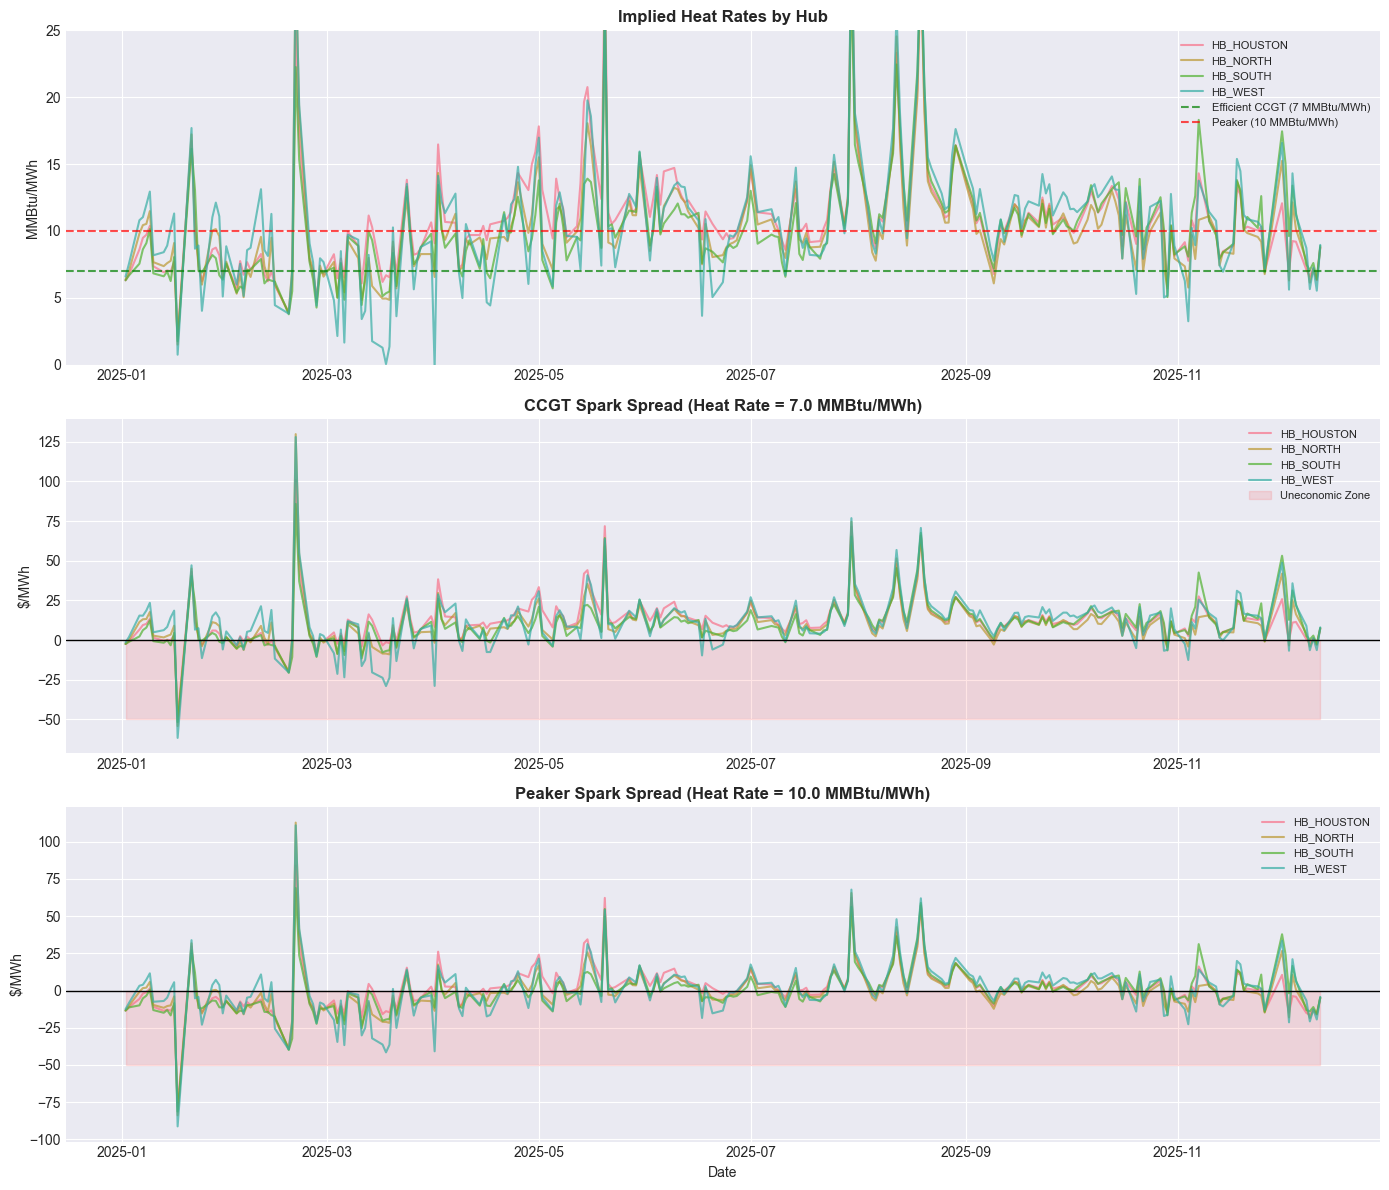

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Implied Heat Rates over time
for hub in analysis_df['Hub'].unique():
    hub_data = analysis_df[analysis_df['Hub'] == hub].set_index('Date')
    axes[0].plot(hub_data.index, hub_data['Implied_Heat_Rate'], label=hub, alpha=0.7)

axes[0].axhline(y=7, color='green', linestyle='--', alpha=0.7, label='Efficient CCGT (7 MMBtu/MWh)')
axes[0].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Peaker (10 MMBtu/MWh)')
axes[0].set_title('Implied Heat Rates by Hub', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MMBtu/MWh')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylim(0, 25)  # Cap for readability

# Plot 2: CCGT Spark Spreads
for hub in analysis_df['Hub'].unique():
    hub_data = analysis_df[analysis_df['Hub'] == hub].set_index('Date')
    axes[1].plot(hub_data.index, hub_data['Spark_Spread_CCGT'], label=hub, alpha=0.7)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].fill_between(analysis_df.set_index('Date').index.unique(), 0, -50, alpha=0.1, color='red', label='Uneconomic Zone')
axes[1].set_title(f'CCGT Spark Spread (Heat Rate = {CCGT_HEAT_RATE} MMBtu/MWh)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('$/MWh')
axes[1].legend(loc='upper right', fontsize=8)

# Plot 3: Peaker Spark Spreads  
for hub in analysis_df['Hub'].unique():
    hub_data = analysis_df[analysis_df['Hub'] == hub].set_index('Date')
    axes[2].plot(hub_data.index, hub_data['Spark_Spread_Peaker'], label=hub, alpha=0.7)

axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[2].fill_between(analysis_df.set_index('Date').index.unique(), 0, -50, alpha=0.1, color='red')
axes[2].set_title(f'Peaker Spark Spread (Heat Rate = {PEAKER_HEAT_RATE} MMBtu/MWh)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('$/MWh')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# To-Do:

- Change colour of lines above to fit fig (1,1).

- Autocorrelation - 24h lags (look at error correction models)
- Change data to hourly. Rework stats for this

- Add cov matrix for inital data.
